# **CS 5361/6361 Machine Learning**

**Linear Regression Exercise**

**Authors:** Miguel Lucero,  Guillermo Beckmann

**Exercise:**

1.  Classify the MNIST dataset using linear regression by simply treating the class as a continuous variable and then rounding the results and clipping to the 0 to 9 range.  
2.  Classify the MNIST dataset using linear regression converting the class to a 10-D vector using a one-hot representation.
3.  Repeat the previous step but now add the squares of the pixel intensities as features.  

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Question 1

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
pred = model.predict(x_test)
pred = (np.round(pred)).astype(int)
pred = np.clip(pred,0,9)
print('Accuracy= {:.5f}'.format(accuracy_score(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

Accuracy= 0.23000
Mean absolute error =  1.36070


#Question 2

In [ ]:
one_hot_y_train = np.zeros((y_train.shape[0],10))
for i in range(y_train.shape[0]):
  one_hot_y_train[i,y_train[i]] = 1

In [ ]:
model.fit(x_train, one_hot_y_train)
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
print(f'Accuracy= {accuracy_score(pred,y_test)}')

Accuracy= 0.8601


#Question 3

In [ ]:
x_train = np.hstack((x_train,x_train**2))
x_test = np.hstack((x_test,x_test**2))
model = LinearRegression()
#model.fit(x_train, y_train)
#pred = model.predict(x_test)
#pred = (np.round(pred)).astype(int)
#pred = np.clip(pred,0,9)

one_hot_y_train = np.zeros((y_train.shape[0],10))
for i in range(y_train.shape[0]):
  one_hot_y_train[i,y_train[i]] = 1

model.fit(x_train, one_hot_y_train)
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
print(f'Accuracy= {accuracy_score(pred,y_test)}')

Accuracy= 0.89


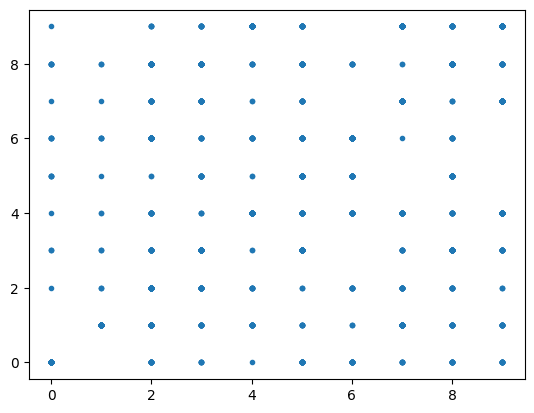

In [ ]:
plt.figure()
plt.plot(y_test,pred,'.')
# print(model.coef_)
# print(model.intercept_)